In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, recall_score, confusion_matrix, roc_auc_score, make_scorer, roc_curve
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, ParameterGrid
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
import xgboost as xgb
from sklearn.utils import resample
import umap

In [2]:
from sdv.single_table import TVAESynthesizer
from sdv.metadata import Metadata

In [3]:
fig_save_dir = r"D:\Singapore\Alzheimer\R files\final data_new\figures\TVAE"
os.makedirs(fig_save_dir, exist_ok=True)

In [4]:
# Load the Excel file
file_path =  r"D:\Singapore\Alzheimer\R files\final data_new\Variable list-11MAY2025.xlsx"
df_Variables = pd.read_excel(file_path)

In [5]:
save_dir = r"D:\Singapore\Alzheimer\R files\final data_new\py"

In [6]:
fig_save_dir = r"D:\Singapore\Alzheimer\R files\final data_new\figures\umap"
os.makedirs(fig_save_dir, exist_ok=True)

In [7]:
file_path_1 = r"D:\Singapore\Alzheimer\R files\final data_new\imoutations_diff_ks\final_data_imputed_k1.csv"
df = pd.read_csv(file_path_1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 677 entries, 0 to 676
Data columns (total 38 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   RID                    677 non-null    int64  
 1   AGE                    677 non-null    int64  
 2   PTGENDER               677 non-null    int64  
 3   PTEDUCAT               677 non-null    int64  
 4   PTRACCAT               677 non-null    int64  
 5   PTMARRY                677 non-null    int64  
 6   APOE4                  677 non-null    int64  
 7   FDG                    677 non-null    float64
 8   AV45                   677 non-null    float64
 9   ABETA                  677 non-null    float64
 10  TAU                    677 non-null    float64
 11  PTAU                   677 non-null    float64
 12  CDRSB                  677 non-null    float64
 13  ADAS11                 677 non-null    float64
 14  ADAS13                 677 non-null    float64
 15  ADASQ4

In [8]:
# Group features based on the "Group" column
demographics = df_Variables[df_Variables['Group'] == 'Demographic']['Predictor'].tolist()
clinical_cognitive = df_Variables[df_Variables['Group'] == 'Clinical/Cognitive']['Predictor'].tolist()
biomarker = df_Variables[df_Variables['Group'] == 'Biomarker']['Predictor'].tolist()
neuroimaging = df_Variables[df_Variables['Group'] == 'Neuroimaging']['Predictor'].tolist()

# Optional: Print or check lists
print("Demographics:", demographics)
print("Clinical/Cognitive:", clinical_cognitive)
print("Biomarker:", biomarker)
print("Neuroimaging:", neuroimaging)

Demographics: ['AGE', 'PTGENDER', 'PTEDUCAT', 'PTRACCAT', 'PTMARRY']
Clinical/Cognitive: ['CDRSB', 'ADAS11', 'ADAS13', 'ADASQ4', 'RAVLT.immediate', 'RAVLT.learning', 'RAVLT.forgetting', 'RAVLT.perc.forgetting', 'LDELTOTAL', 'TRABSCOR', 'FAQ', 'EcogPtTotal', 'MOCA_bl', 'MMSE_bl']
Biomarker: ['FDG', 'AV45', 'ABETA', 'TAU', 'PTAU']
Neuroimaging: ['Ventricles', 'Hippocampus', 'WholeBrain', 'Entorhinal', 'Fusiform', 'MidTemp', 'ICV']


In [9]:
# Group combinations
group_1 = demographics + clinical_cognitive
group_2 = demographics + biomarker
group_3 = demographics + clinical_cognitive + biomarker
group_4 = neuroimaging

In [10]:
print(f'group_1:\n', group_1)
print('*'*100)
print(f'group_2:\n', group_2)
print('*'*100)
print(f'group_3:\n', group_3)
print('*'*100)
print(f'group_4:\n', group_4)

group_1:
 ['AGE', 'PTGENDER', 'PTEDUCAT', 'PTRACCAT', 'PTMARRY', 'CDRSB', 'ADAS11', 'ADAS13', 'ADASQ4', 'RAVLT.immediate', 'RAVLT.learning', 'RAVLT.forgetting', 'RAVLT.perc.forgetting', 'LDELTOTAL', 'TRABSCOR', 'FAQ', 'EcogPtTotal', 'MOCA_bl', 'MMSE_bl']
****************************************************************************************************
group_2:
 ['AGE', 'PTGENDER', 'PTEDUCAT', 'PTRACCAT', 'PTMARRY', 'FDG', 'AV45', 'ABETA', 'TAU', 'PTAU']
****************************************************************************************************
group_3:
 ['AGE', 'PTGENDER', 'PTEDUCAT', 'PTRACCAT', 'PTMARRY', 'CDRSB', 'ADAS11', 'ADAS13', 'ADASQ4', 'RAVLT.immediate', 'RAVLT.learning', 'RAVLT.forgetting', 'RAVLT.perc.forgetting', 'LDELTOTAL', 'TRABSCOR', 'FAQ', 'EcogPtTotal', 'MOCA_bl', 'MMSE_bl', 'FDG', 'AV45', 'ABETA', 'TAU', 'PTAU']
****************************************************************************************************
group_4:
 ['Ventricles', 'Hippocampus', 'Who

In [11]:
target_col = "convert_Within_3Years"

data_group3 = pd.concat(
    [df[group_3], df[target_col]],
    axis=1
)

In [12]:
target_col = "convert_Within_3Years"

data_group3 = pd.concat(
    [df[group_3], df[target_col]],
    axis=1
)

In [13]:
train_data, test_data = train_test_split(
    data_group3,
    test_size=0.30,
    random_state=100,
    stratify=data_group3[target_col]
)

In [14]:
X_train = train_data[group_3]

y_train = train_data[target_col]

In [15]:
print(X_train.shape)
print(y_train.shape)

(473, 24)
(473,)


In [16]:

X_tensor = torch.tensor(
    X_train.values,
    dtype=torch.float32
)

In [17]:
np.random.seed(42)
torch.manual_seed(42)

metadata = Metadata.detect_from_dataframe(train_data)
    

tvae_params = {
    'embedding_dim': 64,
    'compress_dims': (128, 64),
    'decompress_dims': (64, 128),
    'l2scale': 1e-5,
    'batch_size': 64,
    'epochs': 100,
    'loss_factor': 0.5,
    'enforce_min_max_values': True,
    'enforce_rounding': True,
    'enable_gpu': True}

synthesizer = TVAESynthesizer(metadata=metadata, **tvae_params)
synthesizer.fit(train_data)

C:\Users\lotus\anaconda3\Lib\site-packages\sdv\single_table\base.py:134: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


In [18]:
transformed = synthesizer._model.transformer.transform(
    train_data
)

In [19]:
print(transformed.shape)

(473, 116)


In [20]:
X_tensor = torch.tensor(
    transformed,
    dtype=torch.float32
)

In [21]:
with torch.no_grad():

    mu, std, logvar = synthesizer._model.encoder(
        X_tensor
    )

In [22]:
latent_z = mu.numpy()

print(latent_z.shape)

(473, 64)


In [23]:
import umap

umap_model = umap.UMAP(
    n_components=2,
    random_state=42
)

embedding = umap_model.fit_transform(
    latent_z
)

C:\Users\lotus\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


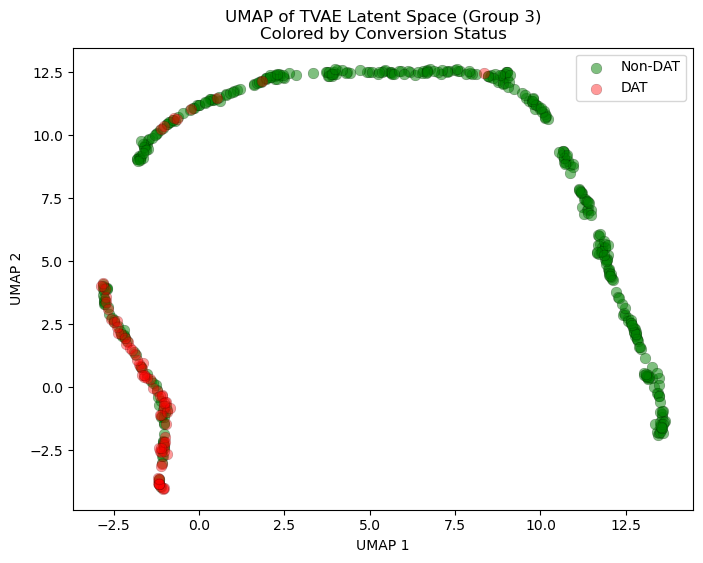

In [24]:
plt.figure(figsize=(8,6))

converter = train_data[target_col] == 1
non_converter = train_data[target_col] == 0

plt.scatter(
    embedding[non_converter,0],
    embedding[non_converter,1],
    color='green',
    alpha=0.5,
    label='Non-DAT',
    s=60,
    edgecolors='black',
    linewidth=0.25
)

plt.scatter(
    embedding[converter,0],
    embedding[converter,1],
    color='red',
    alpha=0.4,
    label='DAT',
    s=60,
    edgecolors='black',
    linewidth=0.25
)

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")

plt.title(
    "UMAP of TVAE Latent Space (Group 3)\nColored by Conversion Status"
)

plt.legend()

plt.savefig(os.path.join(fig_save_dir, f"umap_conv.pdf"), dpi=600, bbox_inches="tight")
plt.show()


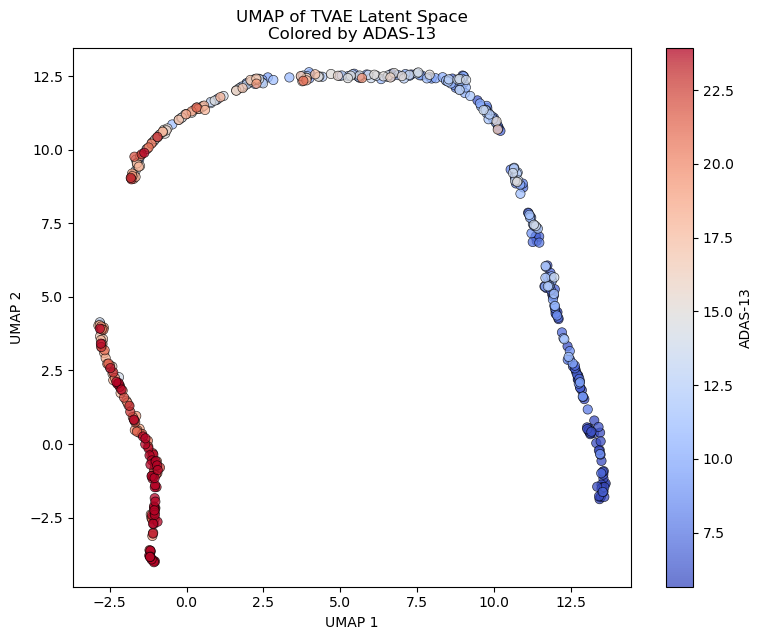

In [25]:
from matplotlib.colors import Normalize

order = np.argsort(train_data['ADAS13'])

vmin = train_data['ADAS13'].quantile(0.10)
vmax = train_data['ADAS13'].quantile(0.90)

plt.figure(figsize=(9,7))

scatter = plt.scatter(
    embedding[order,0],
    embedding[order,1],
    c=train_data['ADAS13'].iloc[order],
    cmap='coolwarm',
    norm=Normalize(vmin=vmin,vmax=vmax),
    alpha=0.75,
    s=45,
    edgecolors='black',
    linewidth=0.5
)

plt.colorbar(
    scatter,
    label='ADAS-13'
)

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")

plt.title(
    "UMAP of TVAE Latent Space\nColored by ADAS-13"
)

plt.savefig(os.path.join(fig_save_dir, f"umap_adas13.pdf"), dpi=600, bbox_inches="tight")
plt.show()


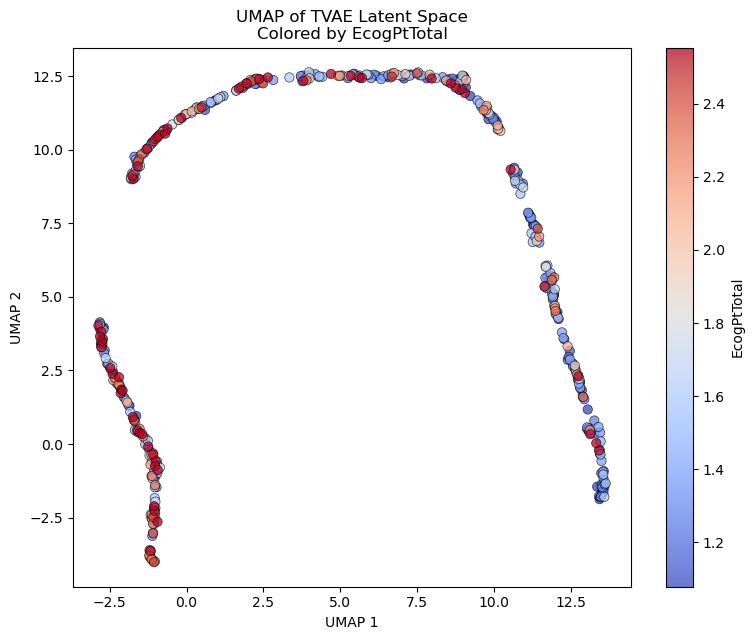

In [26]:
from matplotlib.colors import Normalize

order = np.argsort(train_data['EcogPtTotal'])

vmin = train_data['EcogPtTotal'].quantile(0.10)
vmax = train_data['EcogPtTotal'].quantile(0.90)

plt.figure(figsize=(9,7))

scatter = plt.scatter(
    embedding[order,0],
    embedding[order,1],
    c=train_data['EcogPtTotal'].iloc[order],
    cmap='coolwarm',
    norm=Normalize(vmin=vmin,vmax=vmax),
    alpha=0.75,
    s=45,
    edgecolors='black',
    linewidth=0.5
)

plt.colorbar(
    scatter,
    label='EcogPtTotal'
)

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")

plt.title(
    "UMAP of TVAE Latent Space\nColored by EcogPtTotal"
)

plt.savefig(os.path.join(fig_save_dir, f"umap_EcogPtTotal.pdf"), dpi=600, bbox_inches="tight")
plt.show()

In [27]:
train_data['CDRSB_q'] = pd.qcut(
    train_data['CDRSB'].rank(method='first'),
    q=4,
    labels=['Q1','Q2','Q3','Q4']
)

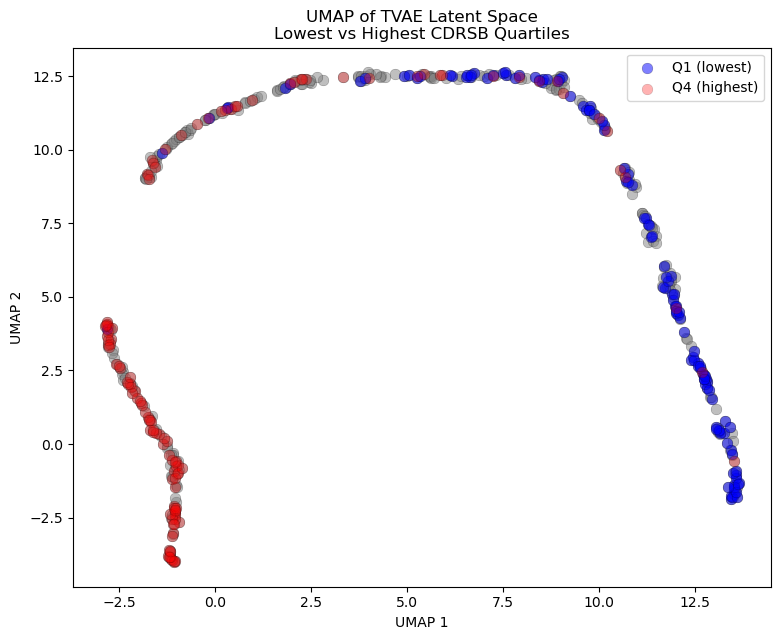

In [28]:
plt.figure(figsize=(9,7))

# background
plt.scatter(
    embedding[:,0],
    embedding[:,1],
    color='gray',
    alpha=0.5,
    s=60,
    edgecolors='black',
    linewidth=0.25
)

# Q1
mask1 = train_data['CDRSB_q']=='Q1'

plt.scatter(
    embedding[mask1,0],
    embedding[mask1,1],
    color='blue',
    alpha=0.5,
    label='Q1 (lowest)',
    s=60,
    edgecolors='black',
    linewidth=0.25
)

# Q4
mask4 = train_data['CDRSB_q']=='Q4'

plt.scatter(
    embedding[mask4,0],
    embedding[mask4,1],
    color='red',
    alpha=0.3,
    label='Q4 (highest)',
    s=60,
    edgecolors='black',
    linewidth=0.25
)

plt.legend()

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")

plt.title(
    "UMAP of TVAE Latent Space\nLowest vs Highest CDRSB Quartiles"
)

plt.savefig(os.path.join(fig_save_dir, f"umap_cdrsb.pdf"), dpi=600, bbox_inches="tight")
plt.show()

In [29]:
train_data['PTAU_q'] = pd.qcut(
    train_data['PTAU'].rank(method='first'),
    q=4,
    labels=['Q1','Q2','Q3','Q4']
)

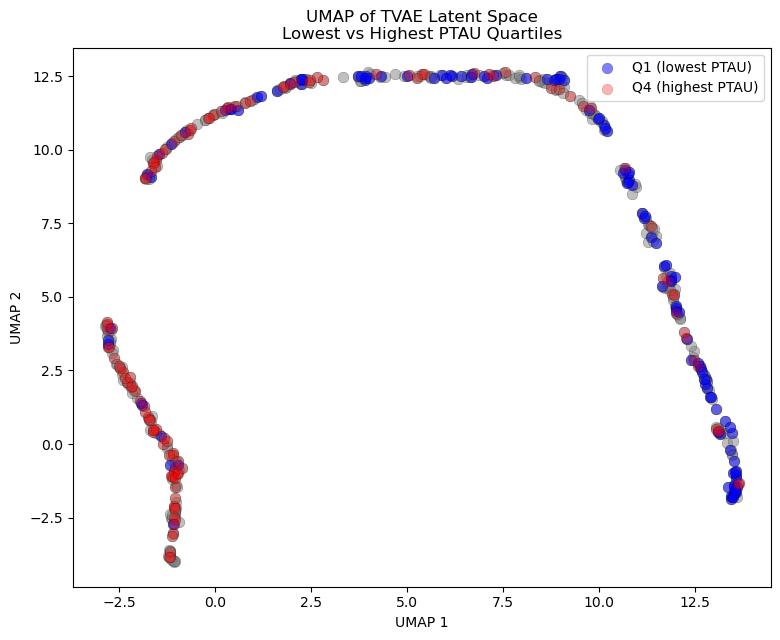

In [30]:
plt.figure(figsize=(9,7))

# background: all patients
plt.scatter(
    embedding[:,0],
    embedding[:,1],
    color='gray',
    alpha=0.50,
    s=60,
    edgecolors='black',
    linewidth=0.25
)

# Lowest PTAU
mask1 = train_data['PTAU_q']=='Q1'

plt.scatter(
    embedding[mask1,0],
    embedding[mask1,1],
    color='blue',
    alpha=0.5,
    label='Q1 (lowest PTAU)',
    s=60,
    edgecolors='black',
    linewidth=0.25
)

# Highest PTAU
mask4 = train_data['PTAU_q']=='Q4'

plt.scatter(
    embedding[mask4,0],
    embedding[mask4,1],
    color='red',
    alpha=0.30,
    label='Q4 (highest PTAU)',
    s=60,
    edgecolors='black',
    linewidth=0.25
)

plt.legend()

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")

plt.title(
    "UMAP of TVAE Latent Space\nLowest vs Highest PTAU Quartiles"
)

plt.savefig(os.path.join(fig_save_dir, f"umap_ptau.pdf"), dpi=600, bbox_inches="tight")
plt.show()

In [31]:
patient_non = train_data[
    train_data[target_col]==0
].iloc[0]

patient_dat = train_data[
    train_data[target_col]==1
].iloc[0]

In [32]:
x_non = synthesizer._model.transformer.transform(
    pd.DataFrame([patient_non])
)

x_dat = synthesizer._model.transformer.transform(
    pd.DataFrame([patient_dat])
)

In [33]:
x_non_tensor = torch.tensor(
    x_non,
    dtype=torch.float32
)

x_dat_tensor = torch.tensor(
    x_dat,
    dtype=torch.float32
)

In [34]:
with torch.no_grad():

    mu_non, _, _ = synthesizer._model.encoder(
        x_non_tensor
    )

    mu_dat, _, _ = synthesizer._model.encoder(
        x_dat_tensor
    )

In [35]:
alphas = np.linspace(0,1,10)

In [36]:
latent_points = []

for a in alphas:

    z = (
        (1-a)*mu_non
        +
        a*mu_dat
    )

    latent_points.append(z)

In [37]:
decoded = []

with torch.no_grad():

    for z in latent_points:

        x_hat, _ = synthesizer._model.decoder(z)

        decoded.append(
            x_hat.numpy()
        )

In [38]:
decoded_array = np.vstack(decoded)

synthetic_interp = synthesizer._model.transformer.inverse_transform(
    decoded_array
)

In [39]:
print(
    synthetic_interp[
        [
            'MMSE_bl',
            'CDRSB',
            'PTAU',
            'FAQ'
        ]
    ].round(3)
)

   MMSE_bl  CDRSB    PTAU    FAQ
0       30  0.004  18.282 -0.024
1       29  0.004  18.450 -0.023
2       29  0.005  18.788 -0.016
3       29  1.809  19.193 -0.008
4       28  1.829  19.471 -0.001
5       26  1.846  19.784  4.556
6       26  1.863  20.120  4.603
7       26  1.883  36.921  4.670
8       26  1.905  37.603  4.757
9       25  1.926  38.305  4.837
